In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20
pheno_list_type = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds_categories.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""genomic_region""","""mane_cds""","""#E31A1C""","""MANE CDS""",1
"""genomic_region""","""non_mane_cds""","""#FB9A99""","""Other CDS""",1
"""genomic_region""","""mane_exonic""","""#33A02C""","""MANE Exon""",1
"""genomic_region""","""non_mane_exonic""","""#B2DF8A""","""Other Exon""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
…,…,…,…,…
"""encode_enhancer""","""encode_ca_ctcf""","""#4DAF4A""","""Accessible Region with CTCF Bi…",1
"""encode_enhancer""","""encode_ca""","""#377EB8""","""Chromatin Accessible""",1
"""encode_enhancer""","""encode_ca_tf""","""#1D6498""","""Accessible Region with TF Bind…",1


In [3]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

min_range = -500
max_range = +500

anno = (
    anno
    .with_columns(
        encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
        encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_annotated = pl.col('not_annotated_in_encode') == False,
        canonical_splice_variant = (pl.col('consequence_splice_acceptor_variant') == True) | (pl.col('consequence_splice_donor_variant') == True)
    )
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True)

        # Choose non CDS only
        # UPDATE WITH NEW VEP MANE ANNOS
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False))

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True)
        # (pl.any_horizontal(cs.contains("consequence_splice") == True))
        # (pl.col('consequence_upstream_gene_variant') == True)
        # (pl.col('consequence_downstream_gene_variant') == True)

        # Choose Introns with/without alternate CDS
        # (pl.col('consequence_intron_variant') == True)
        # ((pl.col('consequence_intron_variant') == True) & (pl.col('non_mane_cds')==False))

        # (pl.col('dist_to_tss') < max_range) &
        # (pl.col('dist_to_tss') > min_range)
        
        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False))

        # Choose regulatory region
        # (pl.col('not_in_encode') == False)
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &
    )
    
    .with_columns(
        loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
        loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_lip_full']),
        loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
        loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    )
    .with_columns(
        indel_length = (pl.col('ref').str.len_chars() - pl.col('alt').str.len_chars()).abs(),
        insertion = pl.when(pl.col('ref').str.len_chars() < pl.col('alt').str.len_chars()).then(True).otherwise(False),
        deletion = pl.when(pl.col('ref').str.len_chars() > pl.col('alt').str.len_chars()).then(True).otherwise(False),
    )
    .with_columns(
        # --- Indel CDS categories ---
        deletion_x3bp = pl.when(pl.col('deletion') & (pl.col('indel_length') %3 == 0)).then(True).otherwise(False),
        deletion_not_x3bp = pl.when(pl.col('deletion') & (pl.col('indel_length') %3 != 0)).then(True).otherwise(False),
        insertion_x3bp = pl.when(pl.col('insertion') & (pl.col('indel_length') %3 == 0)).then(True).otherwise(False),
        insertion_not_x3bp = pl.when(pl.col('insertion') & (pl.col('indel_length') %3 != 0)).then(True).otherwise(False),
    )
    .with_columns(
        # --- ENCODE indels ---
        encode_deletion = pl.when(pl.col('deletion') & (pl.col('encode_annotated')==True)).then(True).otherwise(False),
        encode_insertion = pl.when(pl.col('insertion') & (pl.col('encode_annotated')==True)).then(True).otherwise(False),
        encode_snp = pl.when((pl.col('encode_annotated')==True) & (pl.col('deletion')==False) & (pl.col('insertion')==False)).then(True).otherwise(False),

        # --- ENCODE deletions ---
        encode_deletion_gt2bp = pl.when((pl.col('indel_length') >= 2) & (pl.col('encode_annotated')==True)).then(True).otherwise(False) & pl.col('deletion'),
        encode_deletion_gt5bp = pl.when((pl.col('indel_length') >= 5) & (pl.col('encode_annotated')==True)).then(True).otherwise(False) & pl.col('deletion'),
    )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


five_prime_utr_variant_consequence_ustop_gained,encode_insertion,encode_pls,loftee_low_complexity,region,encode_all_tf,mobi_lip_full,loftee_ted,non_mane_cds,insertion_not_x3bp,consequence_splice_acceptor_variant,encode_deletion,encode_deletion_gt5bp,loftee_lc,dist_to_tss,consequence_splice_donor_variant,insertion,not_annotated_in_encode,id,consequence_stop_lost,encode_tf,gene_name,mane_cds,encode_pels,gene_length,consequence_missense_variant,strand,encode_dels,non_mane_exonic,consequence_start_lost,five_prime_utr_variant_consequence_ustop_lost,five_prime_utr_variant_consequence_uaug_gained,loftee_lip,insertion_x3bp,encode_annotated,deletion_x3bp,low_complexity_domain,loftee_hc,deletion,tss,deletion_not_x3bp,five_prime_utr_variant_consequence_uaug_lost,encode_ca,canonical_splice_variant,loftee_disorder,encode_eh_pr,consequence_stop_gained,encode_deletion_gt2bp,ted_domain,encode_snp,mane_exonic,five_prime_utr_variant_consequence_uframeshift,mobi_curated_disorder_priority,consequence_frameshift_variant
u8,bool,bool,bool,str,bool,bool,bool,bool,bool,i8,bool,bool,i8,i64,i8,bool,bool,str,i8,bool,str,bool,bool,i64,i8,cat,bool,bool,i8,u8,u8,bool,bool,bool,bool,bool,i8,bool,i64,bool,u8,bool,bool,bool,bool,i8,bool,bool,bool,bool,u8,bool,i8
0,false,false,false,"""ENSG00000054938""",false,true,false,false,false,0,false,false,0,20444,0,false,true,"""chr11:74710982:G:C""",0,false,"""CHRDL2""",true,false,34999,1,"""-""",false,false,0,0,0,false,false,false,false,false,0,false,74731426,false,0,false,false,false,false,0,false,false,false,true,0,false,0
0,false,false,false,"""ENSG00000042493""",false,false,false,false,false,0,false,false,0,20276,0,false,false,"""chr2:85398156:G:A""",0,false,"""CAPG""",false,false,23681,0,"""-""",true,false,0,0,0,false,false,true,false,false,0,false,85418432,false,0,false,false,false,true,0,false,false,true,false,0,false,0
0,false,false,false,"""ENSG00000088538""",false,false,false,false,false,0,false,false,0,686918,0,false,true,"""chr3:51361844:C:A""",0,false,"""DOCK3""",false,false,709273,0,"""+""",false,false,0,0,0,false,false,false,false,false,0,false,50674926,false,0,false,false,false,false,0,false,false,false,false,0,false,0
0,false,false,false,"""ENSG00000160049""",false,false,true,false,false,0,false,false,0,8972,0,false,false,"""chr1:10463557:G:A""",0,false,"""DFFA""",true,false,16009,0,"""-""",false,false,0,0,0,false,false,true,false,false,1,false,10472529,false,0,true,false,false,false,1,false,true,true,true,0,false,0
0,false,false,false,"""ENSG00000033170""",false,false,false,false,false,0,false,false,0,258838,0,false,true,"""chr14:65669429:G:A""",0,false,"""FUT8""",true,false,333531,1,"""+""",false,false,0,0,0,false,false,false,false,false,0,false,65410591,false,0,false,false,false,false,0,false,true,false,true,0,false,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,false,false,false,"""ENSG00000170873""",false,true,false,false,false,0,false,false,0,138817,0,false,false,"""chr8:124589656:T:C""",0,false,"""MTSS1""",true,false,177691,1,"""-""",false,false,0,0,0,false,false,true,false,false,0,false,124728473,false,0,false,false,false,false,0,false,false,true,true,0,false,0
0,false,false,false,"""ENSG00000164889""",false,false,false,false,false,0,false,false,0,16993,0,false,false,"""chr7:151074202:C:T""",0,false,"""SLC4A2""",true,false,19318,1,"""+""",true,false,0,0,0,false,false,true,false,false,0,false,151057209,false,0,false,false,false,true,0,false,false,true,true,0,false,0
0,false,false,false,"""ENSG00000137504""",false,true,false,false,false,0,false,false,0,18178,0,false,false,"""chr11:85664730:C:G""",0,false,"""CREBZF""",true,true,25168,1,"""-""",false,false,0,0,0,false,false,true,false,false,0,false,85682908,false,0,false,false,false,true,0,false,false,true,true,0,false,0


In [4]:
# selected_categories = ['genomic_region'] # genomic_region
# selected_categories = ['plof_consequences'] # plof consequences
# selected_categories = ['loftee_hc', 'loftee_lc'] # loftee consequences
# selected_categories = ['plof', 'missense'] # CDS
# selected_categories = ['protein_domains'] # Protein Domains
selected_categories = ['loftee_protein_domains'] # LOFTEE Protein Domains
# selected_categories = ['splicing'] # Splicing
# selected_categories = ['indel_cds'] # CDS indels
# selected_categories = ['indel_categories'] # indel length
# selected_categories = ['encode_boolean'] # encode
# selected_categories = ['encode_indels'] # encode indels
# selected_categories = ['encode_deletions'] # encode deletions
# selected_categories = ['encode_custom'] # encode custom regions
# selected_categories = ['encode_enhancer'] # encode regions
# selected_categories = ['indel_categories', '5utr_annotator', 'encode_boolean'] # 5utr

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

# Handle fillna annotations
anno_fillna = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .select(['id', 'region', 'gene_name'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region', 'gene_name']).lazy(), 
        on=['id', 'region', 'gene_name'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region", "gene_name"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == False
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

melted_anno = (
    anno

    .select(
        set(['id', 'region', 'gene_name']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region", "gene_name"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )
    .with_columns(
        # annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir")
        annotation_score_dircor = (
            pl.when(pl.col("annotation_dir")!=1)
            .then((pl.col('annotation_score')-1).abs())
            .otherwise(pl.col('annotation_score'))
        )
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()
    # .drop_nulls()
    # .filter(pl.col('annotation_score').is_not_null())
)

melted_anno

id,region,gene_name,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,str,f32,str,i8,f32
"""chr5:35876422:C:G""","""ENSG00000168685""","""IL7R""","""loftee_lip""",0.0,"""loftee_protein_domains""",1,0.0
"""chr9:36087712:G:C""","""ENSG00000122707""","""RECK""","""loftee_ted""",0.0,"""loftee_protein_domains""",1,0.0
"""chr18:57609356:C:T""","""ENSG00000134440""","""NARS1""","""loftee_low_complexity""",0.0,"""loftee_protein_domains""",1,0.0
"""chr19:12954481:AATC:A""","""ENSG00000179271""","""GADD45GIP1""","""loftee_disorder""",0.0,"""loftee_protein_domains""",1,0.0
"""chr19:46022837:G:C""","""ENSG00000008438""","""PGLYRP1""","""loftee_ted""",0.0,"""loftee_protein_domains""",1,0.0
…,…,…,…,…,…,…,…
"""chr8:47898475:C:T""","""ENSG00000253729""","""PRKDC""","""loftee_lip""",0.0,"""loftee_protein_domains""",1,0.0
"""chr15:78264820:G:A""","""ENSG00000140403""","""DNAJA4""","""loftee_lip""",0.0,"""loftee_protein_domains""",1,0.0
"""chr22:36326675:C:T""","""ENSG00000100345""","""MYH9""","""loftee_ted""",0.0,"""loftee_protein_domains""",1,0.0


In [5]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet

appv = pl.scan_parquet("/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrela
ted_appv_percentiles.parquet" already exists but -f/--overwrite was not set


In [6]:
# Get gene trait associations
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet -o /home/dnanexus/data_dir/
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/loftee_mac20_associations_bh_corrected.parquet -o /home/dnanexus/data_dir/

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet -o /home/dnanexus/data_dir/

gene_trait_df = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

loftee_corrs = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path
"/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet"
already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000167941""","""heel_bone_mineral_density_bmd_…",0.004143,0.309961,0.309961,1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
…,…,…,…,…,…
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0
"""ENSG00000114796""","""position_of_pulse_wave_notch_i…",0.03963,-0.003476,0.003476,-1.0


In [7]:
n_steps = 101
or_threshold_pheno_left = 1
or_threshold_pheno_right = 1e-6

cutoffs_list = 1 - np.logspace(
    np.log10(or_threshold_pheno_left),
    np.log10(or_threshold_pheno_right),
    num=n_steps
)

pheno_cutoffs_lazy = pl.LazyFrame({"pheno_cutoff": cutoffs_list.tolist()})

pheno_cutoffs_lazy.collect()

pheno_cutoff
f64
0.0
0.129036
0.241422
0.339307
0.42456
…
0.999998
0.999998
0.999999


In [8]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())

# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    # Select required variants
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    # Merge annotation scores
    .join(
        melted_anno.lazy(),
        on="id", 
        how="inner"
    )
    # Merge with gene_trait_df
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('loftee_corr_dir') == -1) # To get 1/100, 1/1000, etc.
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
    
    # Cross join with cutoffs and compute odds ratios
    .join(
        pheno_cutoffs_lazy, 
        how="cross"
    )
    .group_by(["annotation", "region", "gene_name", "phenotype", "pheno_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor") == 1) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= pl.col("pheno_cutoff"))
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor") == 1) & 
            (pl.col("mean_pheno_value_dircor_ptile") < pl.col("pheno_cutoff"))
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor") == 0) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= pl.col("pheno_cutoff"))
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor") == 0) & 
            (pl.col("mean_pheno_value_dircor_ptile") < pl.col("pheno_cutoff"))
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = gp_lazy.collect(engine='streaming').sort('pheno_cutoff')

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,pheno_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""loftee_disorder""","""ENSG00000107863""","""ARHGAP21""","""trunk_predicted_mass_int""",0.0,0,0,1366,0,NaN
"""loftee_ted""","""ENSG00000147324""","""MFHAS1""","""hdl_cholesterol_int""",0.0,42,0,1057,0,NaN
"""loftee_disorder""","""ENSG00000168016""","""TRANK1""","""standing_height_int""",0.0,0,0,2167,0,NaN
"""loftee_lip""","""ENSG00000237441""","""RGL2""","""lymphocyte_count_int""",0.0,11,0,630,0,NaN
"""loftee_disorder""","""ENSG00000103657""","""HERC1""","""standing_height_int""",0.0,0,0,3439,0,NaN
…,…,…,…,…,…,…,…,…,…
"""loftee_ted""","""ENSG00000165029""","""ABCA1""","""apolipoprotein_a_int""",0.999999,0,37,0,1544,NaN
"""loftee_low_complexity""","""ENSG00000038358""","""EDC4""","""high_light_scatter_reticulocyt…",0.999999,0,4,0,1052,NaN
"""loftee_ted""","""ENSG00000153560""","""UBP1""","""forced_vital_capacity_fvc_best…",0.999999,0,6,0,301,NaN


In [9]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

print('unique percentile cutoffs:', or_df['pheno_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['pheno_cutoff', 'annotation']),
        pheno_cutoff_inv = 1 - pl.col('pheno_cutoff'),
    )
    .with_columns(
        neg_log_pheno_cutoff_inv = -np.log10(pl.col('pheno_cutoff_inv')),
        med_odds_ratio = pl.col('odds_ratio').median().over(['pheno_cutoff_inv', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['pheno_cutoff_inv', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['pheno_cutoff_inv', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'neg_log_pheno_cutoff_inv', 'pheno_cutoff', 'pheno_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    
    # join plotting info
    .join(
        anno_config_df.select(['annotation', 'color', 'label']).unique(),
        on='annotation',
        how='left'
    )
    .sort('pheno_cutoff_inv')

    # Remove data points without ci or with or=0
    .filter(
        (pl.col('std_ci_upper').is_not_null()) &
        (pl.col('std_ci_lower').is_not_null()) &
        (pl.col('n_gene_phenos') >= 20) &
        (pl.col('avg_odds_ratio') > 0) &
        (pl.col('std_ci_lower') > 0)
    )
)

plt_df

unique percentile cutoffs: 101


annotation,neg_log_pheno_cutoff_inv,pheno_cutoff,pheno_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,f64,f64,u64,f64,f64,f64,f64,f64,str,str
"""loftee_lip""",5.46,0.999997,0.000003,63,0.0,3.061508,1.541625,6.083093,0.039923,"""#1E90FF""","""LIP domain"""
"""loftee_lip""",5.4,0.999996,0.000004,71,0.0,3.351859,1.498123,6.288179,0.415538,"""#1E90FF""","""LIP domain"""
"""loftee_lip""",5.34,0.999995,0.000005,77,0.0,2.967236,1.340517,5.594649,0.339824,"""#1E90FF""","""LIP domain"""
"""loftee_ted""",5.34,0.999995,0.000005,83,0.0,7.238986,3.271975,13.652056,0.825916,"""#2E8B57""","""Structured Domain"""
"""loftee_ted""",5.28,0.999995,0.000005,87,0.0,4.659342,1.819041,8.224661,1.094022,"""#2E8B57""","""Structured Domain"""
…,…,…,…,…,…,…,…,…,…,…,…
"""loftee_lip""",0.9,0.874107,0.125893,22,1.540346,1.992374,0.383317,2.743677,1.241072,"""#1E90FF""","""LIP domain"""
"""loftee_lip""",0.84,0.855456,0.144544,22,1.398263,1.887389,0.346398,2.56633,1.208448,"""#1E90FF""","""LIP domain"""
"""loftee_ted""",0.84,0.855456,0.144544,24,2.553358,3.251479,0.54548,4.32062,2.182339,"""#2E8B57""","""Structured Domain"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


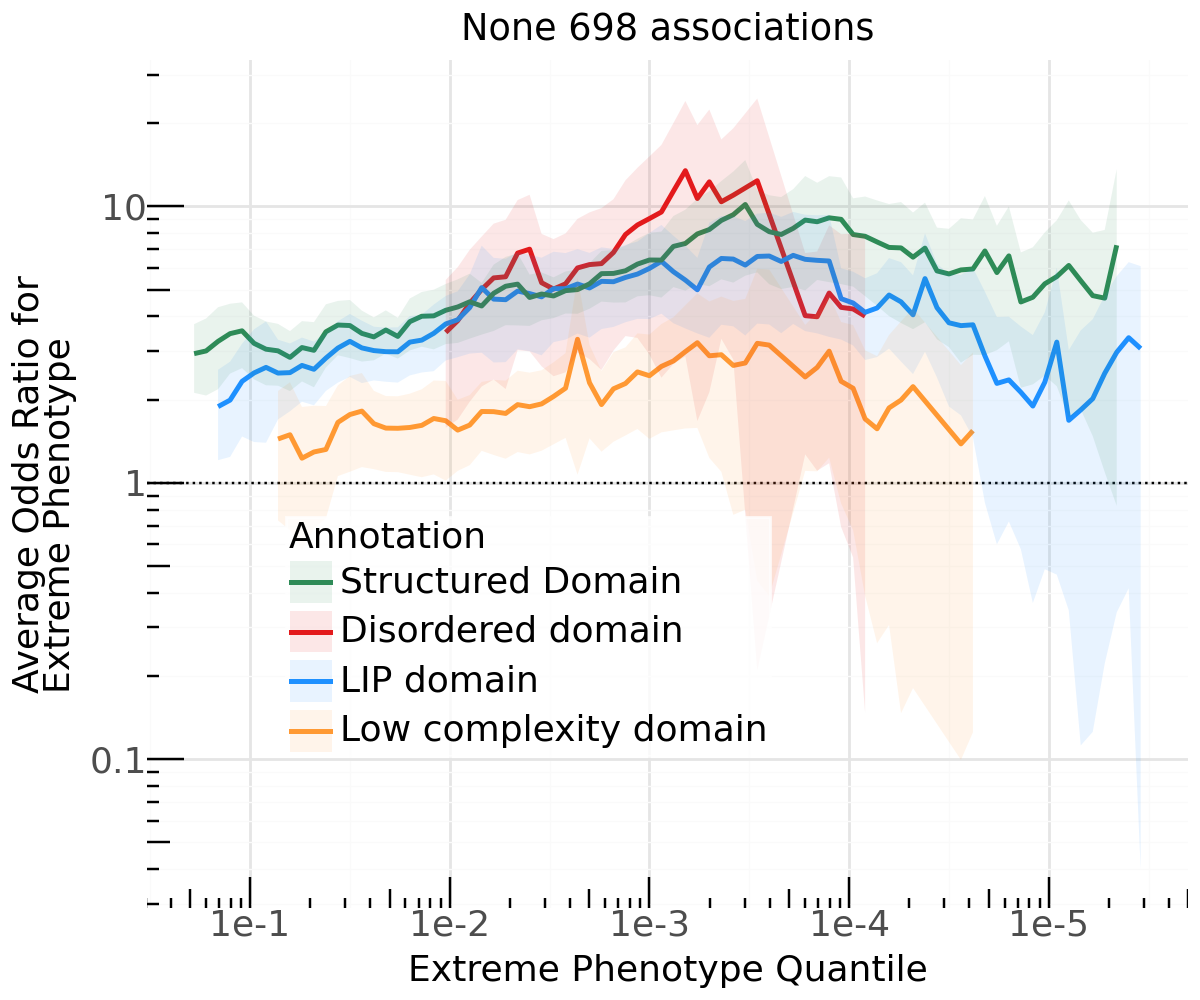

In [10]:
# Determine legend order based on final average odds ratio
legend_order = (
    plt_df.sort("neg_log_pheno_cutoff_inv")
    .group_by("label", maintain_order=True)
    .last()
    .sort("avg_odds_ratio", descending=True)
    ['label']
    .to_list()
)

# Generate breaks and labels for x-axis
start_exp = int(-np.log10(or_threshold_pheno_left))
end_exp = int(-np.log10(or_threshold_pheno_right))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e-{b}" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))

(
    ggplot(
        plt_df,
        aes(x='neg_log_pheno_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict, limits=legend_order)
    + scale_color_manual(values=color_dict, limits=legend_order)
    + labs(
        title=f"{pheno_list_type} {or_df[['gene_name', 'phenotype']].unique().shape[0]} associations",
        y=f"Average Odds Ratio for\nExtreme Phenotype",
        x="Extreme Phenotype Quantile",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(6, 5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.25, 0.25), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [11]:
plt_df.filter(
    (pl.col('pheno_cutoff')==0.99)
    # (pl.col('annotation').is_in(['loftee_hc']))
)

annotation,neg_log_pheno_cutoff_inv,pheno_cutoff,pheno_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,f64,f64,u64,f64,f64,f64,f64,f64,str,str


In [12]:
melted_anno.filter(
    (pl.col('annotation')=='canonical_splice_variant') &
    (pl.col('annotation_score_dircor')==1)
)

id,region,gene_name,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,str,f32,str,i8,f32
